In [1]:
import sys
sys.path.append('../')

from config import *
from figs_config import *

Loaded aesthetics module


# Microarray gene expression

This section contains code for visualizing **raw data**, **cross-validation samples**, and for conducting **variography**

In [2]:
# define some coours
import matplotlib.pyplot as plt

cv_colour = plt.cm.Blues(0.2) # something blue
og_colour = plt.cm.Blues(0.7) # something blue and assertively so
test_colour = plt.cm.summer(0.2) # something green

## Variography of CV samples for microarray probes

* map coordinates to the same space

In [3]:
# Bring DSK33 parcel centroid coordinates to MNI space
import joblib
ctx_dsk33 = joblib.load(projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')
mni_cents = fslr_to_mni_coords_transform(coords = ctx_dsk33[2], inverse=False)

In [4]:
trg_pvdata = joblib.load(projdir + '/data/fsLR-4k_reduced-midthickness_beliveau.pkl')
mni_pet = fslr_to_mni_coords_transform(coords = trg_pvdata.points, inverse=False)

In [32]:
src_pvdata = joblib.load(projdir + '/data/icbm09c_cic-volume_microarray-pet.pkl')

In [6]:
src_pvdata.n_points

3468

## Choosing covariates

In [7]:
import run_wrappers

Yk0, yk1 = run_wrappers.generate_covariates(curr_map=f'mrna_HTR1A', \
                                        src_polydata=src_pvdata, \
                                        trg_polydata=src_pvdata, \
                                        nspins=3000, datasource='microarray-pet')

mrna_HTR1A
['pet_satterthwaite2014_meancbf' 'pet_finnema2016_ucbj'
 'pet_dubois2015_abp688' 'pet_rosaneto_abp688' 'pet_smart2019_abp688']
[0.36278967 0.40029774 0.44643787 0.45184278 0.51238959]


/home/yzhou/anaconda3/envs/py311/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


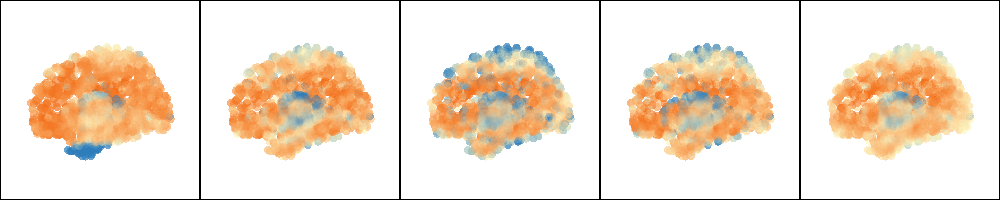

In [10]:
import pyvista as pv

covariates = ['pet_satterthwaite2014_meancbf', 'pet_finnema2016_ucbj', \
 'pet_dubois2015_abp688', 'pet_rosaneto_abp688', 'pet_smart2019_abp688']

pl = pv.Plotter(shape=(1,5), window_size = (1000,200))

l_src_pvdata = joblib.load(projdir + '/data/icbm09c_left-volume_microarray-pet.pkl')

for i in range(5):
    pl.subplot(0,i)

    pl.add_points(pv.PolyData(l_src_pvdata.points).rotate_z(180), scalars = l_src_pvdata[covariates[i]], point_size = 8, \
                  clim = (np.percentile(src_pvdata[covariates[i]], 5), np.percentile(l_src_pvdata[covariates[i]], 95)),\
                  cmap = gnrd, opacity = .7, show_scalar_bar=False, **point_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend='static')
#pl.save_graphic(projdir + '/figs/main/supplements_usecase_alpha_covariates_example.svg')

In [11]:
curr_map = 'mrna_HTR1A'
other_maps = src_pvdata.array_names[5:]

CMAT = np.ones(len(other_maps))

for j, other_map in enumerate(other_maps):

    CMAT[j] = np.ma.corrcoef(np.ma.masked_invalid(src_pvdata[curr_map]), \
                    np.ma.masked_invalid(src_pvdata[other_map]))[1,0]

In [12]:
np.nanmax(CMAT)

np.float64(0.512389591735788)

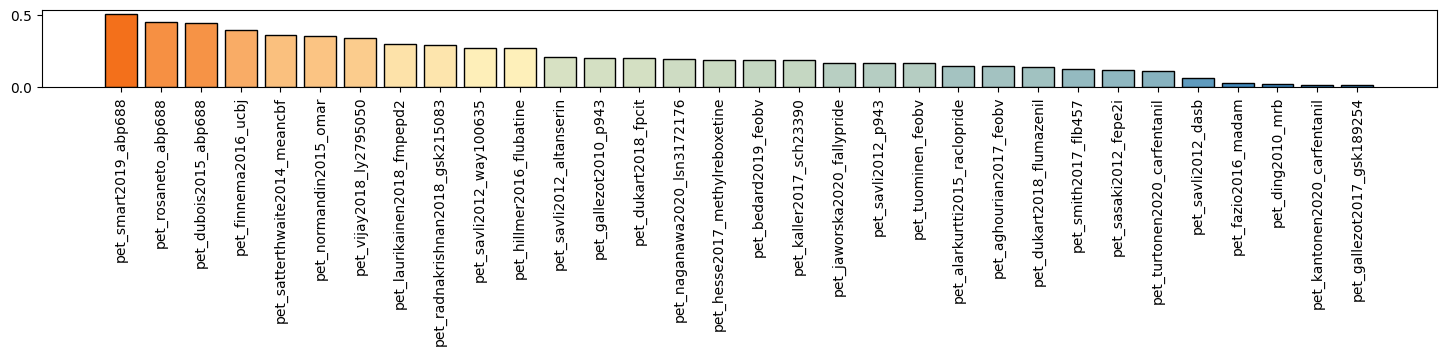

In [13]:
import matplotlib.pyplot as plt
values = abs(CMAT)
hvals = values[ values.argsort()][::-1]
colors = [ gnrd(value/np.nanmax(CMAT)) for value in hvals ]

plt.figure(figsize = (18,1))
plt.bar(x=np.array(other_maps)[values.argsort()][::-1], height=hvals, color=colors, edgecolor = 'k')
plt.ylim = ([0.0, 0.40])
plt.xticks(ticks=np.array(other_maps)[values.argsort()][::-1], labels = np.array(other_maps)[values.argsort()][::-1], rotation=90)

plt.show()

* inspect distance bins

In [14]:
from interpmodules import helpers

src_EDist = helpers.internal_distance_matrix(src_pvdata.points)

In [15]:
nh = 25
bin_edges = np.linspace(0.000001, src_EDist.max(), nh + 1)

In [16]:
# distance bins between dsk 33 parcel centroids and every point in the microarray sample sets

import matplotlib.pyplot as plt


median_dist = np.zeros(mni_cents.shape[0])
parcel_dist = np.zeros((mni_cents.shape[0], src_pvdata.points.shape[0]))


for j in range(mni_cents.shape[0]):

    dj = helpers._get_distance_between(mni_cents[j,:].reshape(1,-1), src_pvdata.points)

    median_dist[j] = np.median(dj)
    parcel_dist[j,:] = dj

In [17]:
mdist_order = np.arange(mni_cents.shape[0])[ median_dist.argsort() ]

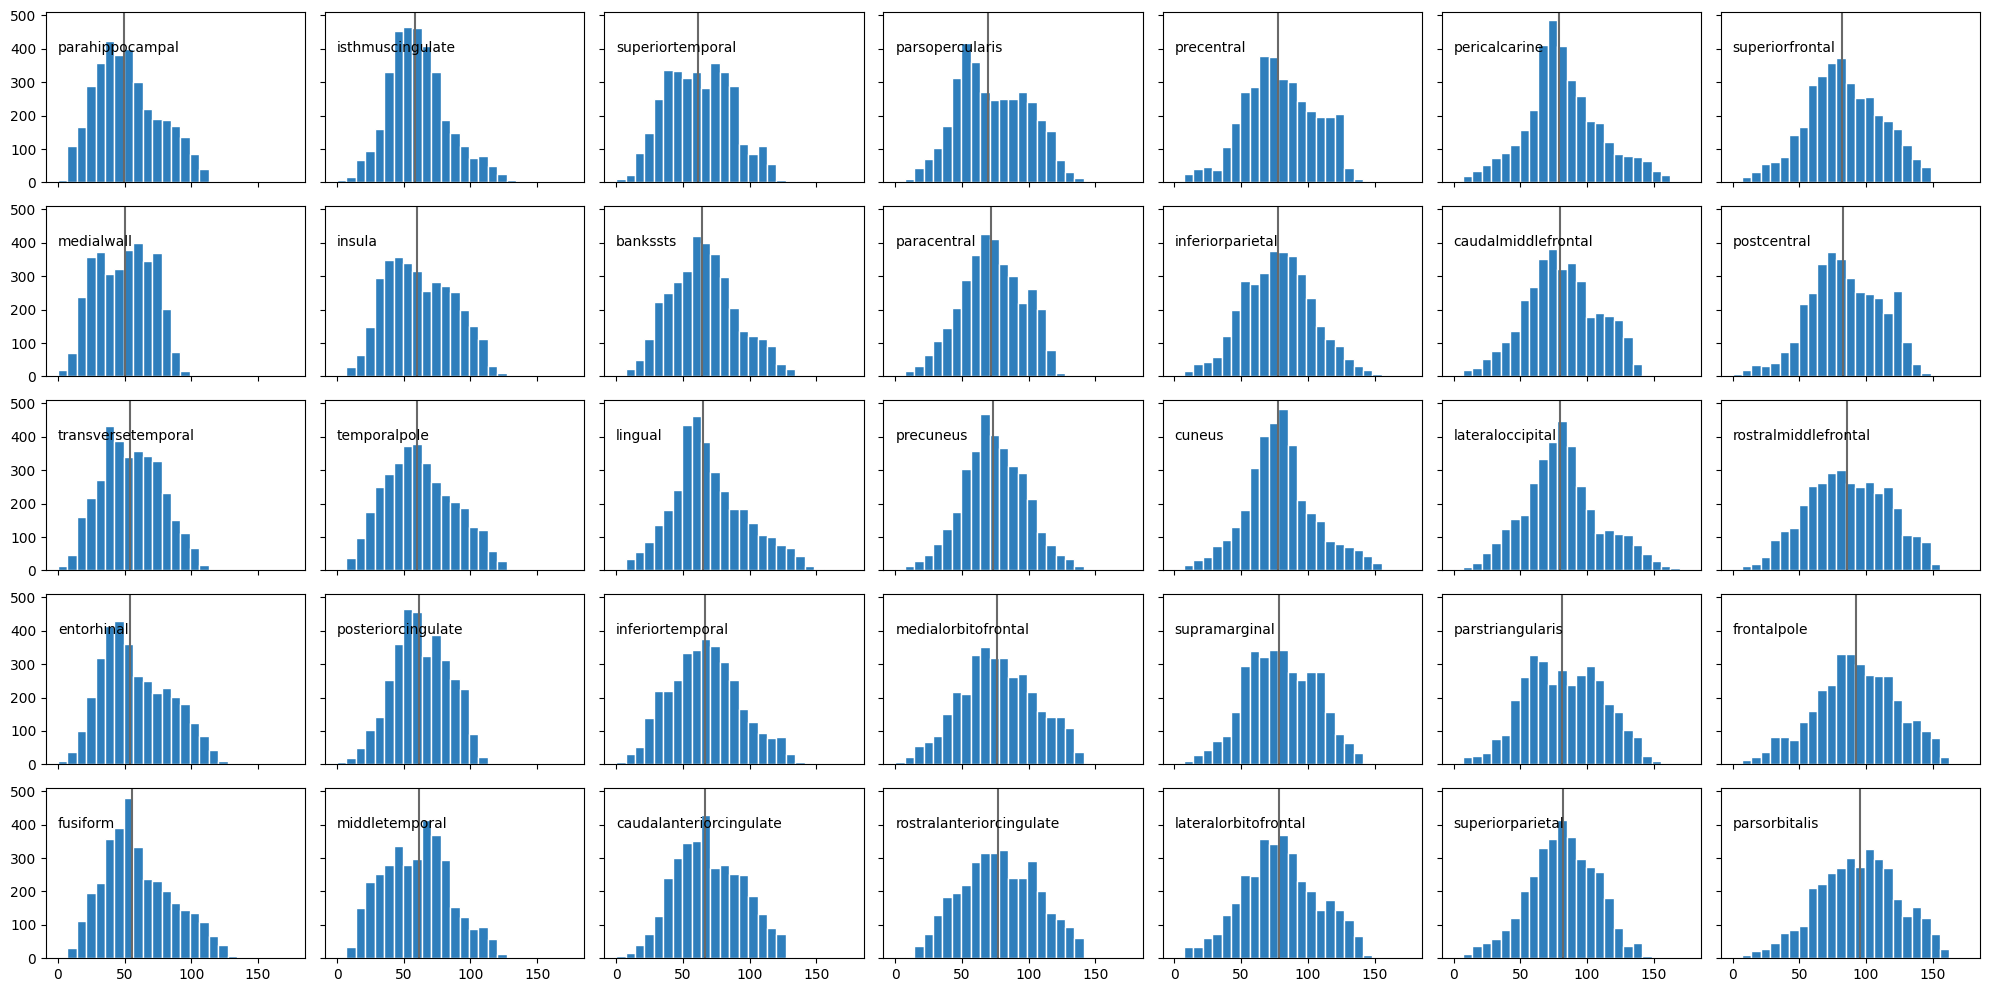

In [18]:
# Plotting the distance bins

fig, axs = plt.subplots(5,7, figsize = (20,10), sharex=True, sharey=True)

for ji, j in enumerate(mdist_order):
    
    row, col = ji % 5, ji // 5

    dj = parcel_dist[j,:]
    
    axs[row, col].hist(dj.flatten(), bins = bin_edges, facecolor=to_hex(og_colour), edgecolor = 'w')
    axs[row, col].axvline(median_dist[j], color = 'dimgray')
    axs[row, col].text(x=0, y=390, s=ctx_dsk33[0][j], color = 'k')

plt.tight_layout()

* load cross-validation sample sets

In [19]:
cv_train_coords, cv_train_verts, cv_test_coords, cv_test_verts = [], [], [], []


for ji in range(mni_cents.shape[0]):

    train_coords, train_verts, test_coords, test_verts = helpers.cv_distdep_noreplace(pvdata=src_pvdata, \
                                                                                      center=mni_cents[ji,:], \
                                                                                      nfolds=5, rseed=321)
    cv_train_coords.append(train_coords)
    cv_train_verts.append(train_verts)
    cv_test_coords.append(test_coords)
    cv_test_verts.append(test_verts)

* compute variogram for the cortical microarray map

In [20]:
from scipy.stats import zscore

gene = 'HTR1A'

z_fullsparse = zscore( src_pvdata[f'mrna_{gene}'] )

h, ev, nbin = helpers.get_empirical_variogram_fast(x=z_fullsparse, \
                                                  X=src_pvdata.points, \
                                                  D = src_EDist,\
                                                h_bounds = bin_edges, \
                                                  nh = nh)
z_fullsparse_vgm = (h,ev)

In [21]:
import pandas as pd

N = dict.fromkeys(['euclidean', 'geodesic'])

In [52]:
def get_bin_centers(bin_edges):

    return (bin_edges[:-1] + bin_edges[1:]) / 2

In [22]:
from scipy.sparse import coo_matrix
from scipy.spatial import KDTree

max_lag = np.nanmax(src_EDist)
tree = KDTree(src_pvdata.points)
x = src_pvdata['mrna_HTR1A']
spdist = tree.sparse_distance_matrix(tree, max_distance=max_lag, output_type='coo_matrix')

i_idx = spdist.row
j_idx = spdist.col
dist_ij = spdist.data

df = pd.DataFrame({
    'h': dist_ij,
})

bin_edges = np.linspace(0.000001, max_lag, nh + 1)
df['bins'] = pd.cut(df['h'], bin_edges)

N['euclidean'] = df.groupby('bins')['h'].count().values

In [23]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,nh))
cmap_discrete = ListedColormap(colors)

Text(0.5, 0, 'Euclidean Distance (mm)')

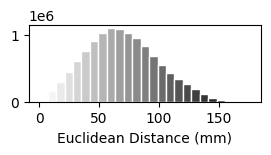

In [24]:
figs, ax = plt.subplots(1,1, figsize = (3,1))

bin_edges = np.linspace(0.000001, np.nanmax(src_EDist), nh + 1)
bincenters = [ ( bin_edges[i] + bin_edges[i + 1] ) / 2 for i in range(nh) ]
binwidth = bincenters[1] - bincenters[0]

ax.bar(x=bincenters, height=N["euclidean"], align = 'center', edgecolor = 'w', color = colors, width=binwidth)
ax.set_xlabel("Euclidean Distance (mm)")

In [25]:
np.where(N['euclidean'] == N['euclidean'].max())

(array([8]),)

In [26]:
bin_edges[7], bin_edges[8]

(np.float64(49.45663575014779), np.float64(56.52186928588319))

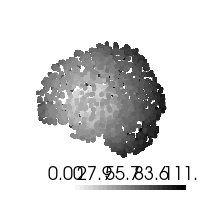

In [33]:
import copy
import pyvista as pv
from matplotlib.colors import ListedColormap
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(window_size = (200,200))

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=src_EDist[100], opacity=1, cmap = cmap_discrete, point_size = 5, **point_aes)
pl.camera_position = 'yz'

#pl.subplot(0,1)
#pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=GDist[20], opacity =1, cmap = cmap_discrete, **mesh_aes)
#pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')


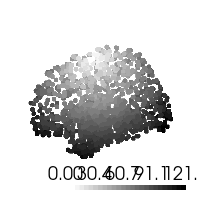

In [34]:
import copy
import pyvista as pv
from matplotlib.colors import ListedColormap
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(window_size = (200,200))

l_src_EDist = helpers.internal_distance_matrix(l_src_pvdata.points)

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_points(pv.PolyData(l_src_pvdata).rotate_z(180), scalars=l_src_EDist[100], opacity=1, cmap = cmap_discrete, point_size = 5, **point_aes)
pl.camera_position = 'yz'

#pl.subplot(0,1)
#pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=GDist[20], opacity =1, cmap = cmap_discrete, **mesh_aes)
#pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

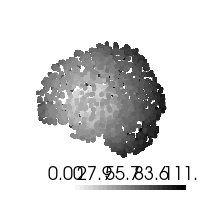

In [35]:
import copy
import pyvista as pv
from matplotlib.colors import ListedColormap
N=25
cmap_cont = plt.cm.gist_yarg

colors = cmap_cont(np.linspace(0,1,N))
cmap_discrete = ListedColormap(colors)

pl = pv.Plotter(window_size = (200,200))

#pl.add_points(sphere_mesh.points[12], color = 'r', point_size = 12,  **point_aes)
pl.subplot(0,0)
pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=src_EDist[100], opacity=1, cmap = cmap_discrete, point_size = 5, **point_aes)
pl.camera_position = 'yz'

#pl.subplot(0,1)
#pl.add_points(pv.PolyData(src_pvdata).rotate_z(180), scalars=GDist[20], opacity =1, cmap = cmap_discrete, **mesh_aes)
#pl.camera_position = 'yz'

pl.show(jupyter_backend = 'static')

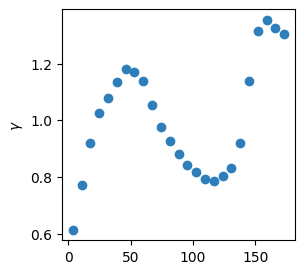

In [36]:
import matplotlib.pyplot as plt

p = plt.figure( figsize = (3,3) )

plt.scatter(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour)
plt.ylabel(r"$\gamma$")

plt.show()

In [37]:
# fitting multiple variograms

import gstools as gs
from interpmodules import helpers
import skgstat as skg
skgstat_mdls = {'spherical': skg.models.spherical, 
                'exponential': skg.models.exponential,
                'gaussian': skg.models.gaussian,
                'cubic': skg.models.cubic,
                'stable': skg.models.stable,
                'matern': skg.models.matern,
               'hole': helpers.hole}

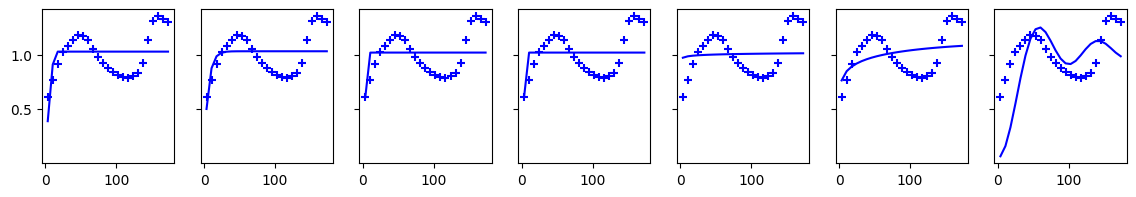

In [40]:
import matplotlib.pyplot as plt
import skgstat as skg
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
from interpmodules import metrics

fig, axs = plt.subplots(1,7, figsize = (14,2), sharex=True,sharey=True)

model_scores = {}

h, ev = z_fullsparse_vgm
nh = 25
bounds = {3: ([0.00001]*3, [np.max(h), np.nanmax(ev), np.nanmax(ev)/nh]),
          4: ([0.00001]*4, [np.max(h), np.nanmax(ev), np.nanmax(ev)/nh, 1])
         }

cof = None; cov = None

gof = {}

for ind, model in enumerate(skgstat_mdls):

    axs[ind].scatter(h, ev, marker = "+", color = 'b')
    

    if model in ['stable', 'matern']:
        cof, cov = curve_fit(skgstat_mdls[model], h, ev, method = 'trf', p0 = bounds[4][1], bounds = bounds[4], maxfev=1000)
    
    else:
        cof, cov = curve_fit(skgstat_mdls[model], h, ev, method = 'trf', p0 = bounds[3][1], bounds = bounds[3], maxfev=1000)

    v_pred = skgstat_mdls[model](h, *cof)
    x_s = np.linspace(h.min(), h.max())
    axs[ind].plot(h, v_pred, color = 'b')
    mae = np.mean(metrics.metric(v_pred, ev, 'residual'))
    gof[model] = mae
    #axs[ind].text(x=0, y=2,s= model + "\n" + r'MAE=' + '{0:.2f}'.format(mae))


In [41]:
gof

{'spherical': np.float64(0.16266537138884804),
 'exponential': np.float64(0.15530344642684513),
 'gaussian': np.float64(0.1582357570687762),
 'cubic': np.float64(0.15816014949569696),
 'stable': np.float64(0.17248429622471306),
 'matern': np.float64(0.16682771288819218),
 'hole': np.float64(0.2307466657600608)}

In [44]:
cof, cov = curve_fit(skgstat_mdls['hole'], h, ev, method = 'trf', p0 = bounds[3][1], bounds = bounds[3], maxfev=1000)

In [45]:
cof

array([38.85830727,  0.98507859,  0.05417278])

In [79]:
import gstools as gs

mdl = gs.covmodel.JBessel(dim=1, var=cof[1]+cof[2], len_scale=helpers._convert_to_length(cof[0]), nugget=cof[2])

<Axes: >

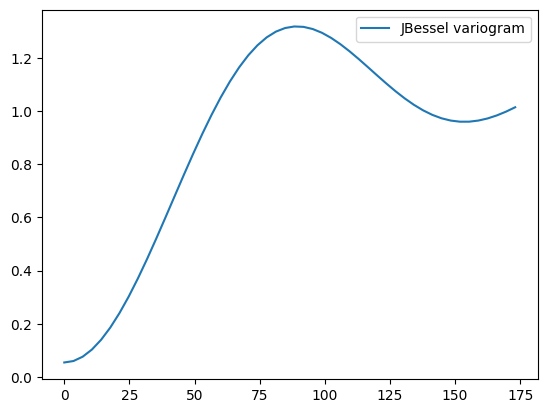

In [80]:
gs.covmodel.plot.plot_variogram(mdl, x_min=0, x_max = h.max())

* compute variogram for the whole PET map

In [42]:
fulldense = trg_pvdata[f'pet_beliveau2017_cumi101']
z_fulldense = zscore(fulldense)

trg_EDist = helpers.internal_distance_matrix(mni_pet)

h, ev, nbin = helpers.get_empirical_variogram_fast(x=z_fulldense, \
                                                  X=mni_pet, \
                                                  D=trg_EDist, \
                                                   h_bounds=bin_edges, \
                                                  nh = nh)

z_fulldense_vgm = (h,ev,nbin)

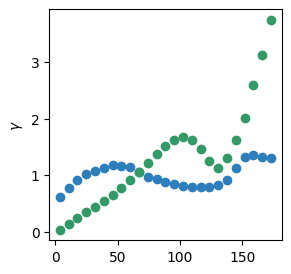

In [43]:
plt.figure(figsize = (3,3))
plt.scatter(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour)
plt.scatter(z_fulldense_vgm[0], z_fulldense_vgm[1], color = test_colour)
plt.ylabel(r"$\gamma$")

plt.show()

^^ before sill standardization

In [44]:
nfolds = 5

ev_s = []
expvgm_parcel = []
expvgm_distbin = []

for ji in range(mni_cents.shape[0]):
    for fi in range(nfolds):
        h,ev,nbins = helpers.get_empirical_variogram_fast(x=z_fullsparse[cv_train_verts[ji][fi]], \
                                    X=cv_train_coords[ji][fi], \
                                    D=parcel_dist[ji,:], \
                                    h_bounds = bin_edges, \
                                    nh=nh)
        ev_s.append(ev)
        expvgm_parcel.append(ji)
        expvgm_distbin.append(fi)

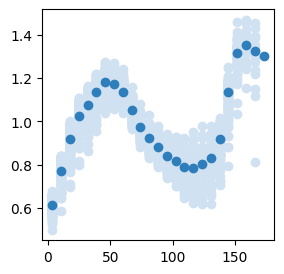

In [45]:
plt.figure(figsize = (3,3))

for si in range(len(ev_s)):
    plt.scatter(h,ev_s[si],color=cv_colour)
plt.scatter(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour)
plt.show()

In [49]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

N = 5
cmap = plt.cm.Grays
colors = cmap(np.linspace(0.2, .7, N))
distbinmap = mcolors.ListedColormap(colors, name="wcuhe34")

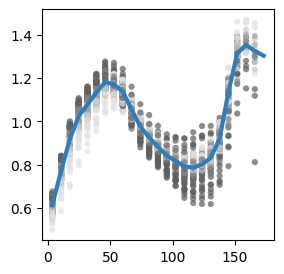

In [54]:
plt.figure(figsize = (3,3))
for si in range(len(ev_s)):
    plt.scatter(x=get_bin_centers(bin_edges), y=ev_s[si], edgecolor = 'none', s=20, alpha = 0.7, color=distbinmap(expvgm_distbin[si]), rasterized=True)
plt.plot(z_fullsparse_vgm[0], z_fullsparse_vgm[1], color = og_colour, linewidth = 3)
plt.show()

In [63]:
import skgstat as skg

binned_vario = skg.Variogram(coordinates = src_pvdata.points, \
             values = z_fullsparse, \
             model = "exponential", \
             n_lags = 25, bin_func = 'even', use_nugget = True)

x, y = binned_vario.get_empirical(bin_center=True) # this gives the same result as my own code

bounds = (0.00001, [np.nanmax(x), np.nanmax(y), np.nanmax(y)/10])
binned_vario.fit(force=True, method = 'trf', p0=bounds[1], maxfev=1000)

theoretical = binned_vario.transform(x)

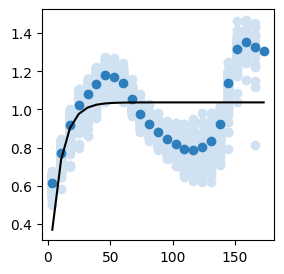

In [70]:
plt.figure(figsize = (3,3))

for si in range(len(ev_s)):
    plt.scatter(h,ev_s[si],color=cv_colour)
    
plt.scatter(h, z_fullsparse_vgm[1],color=og_colour)
plt.plot(h, theoretical, color = 'k')
plt.show()

In [65]:
from interpmodules import metrics

mae_og = np.mean( metrics.metric(theoretical, y , method='residual') )

In [66]:
mae_cv = []

for si in range(len(ev_s)):
    
    mae_cv.append(np.nanmean( metrics.metric(theoretical, ev_s[si], method='residual') ))

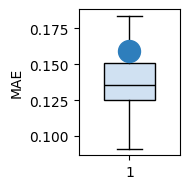

In [67]:
plt.figure(figsize = (2,2))

b = plt.boxplot(mae_cv, widths = 0.5, showfliers=False, patch_artist=True, 
            medianprops=dict(color='k', linewidth=1),\
           whiskerprops=dict(color='k', linewidth=1),\
           capprops=dict(color='k', linewidth=1),\
           boxprops=dict(color='k', linewidth=1)
)

b['boxes'][0].set_facecolor(cv_colour)
plt.scatter(x=1, y=mae_og, color=og_colour, s=250, zorder = 10)
plt.ylabel('MAE')
ax.set_ylim(0.07, 0.2)
plt.tight_layout()

In [68]:
p = (np.sum(np.abs(mae_cv - np.mean(mae_cv)) >= np.abs(mae_og - np.mean(mae_cv))) + 1) / (len(mae_cv) + 1)

In [69]:
p

np.float64(0.2727272727272727)

### full plot

In [74]:
joined_vgm = np.vstack(ev_s + [z_fullsparse_vgm[1]] + [theoretical])

In [75]:
# scale the dense one wrt the sparse one
target_sill = np.nanmax(z_fullsparse_vgm[1])  # ≈ 1.2
current_sill = np.nanmax(z_fulldense_vgm[1])

scaled_fulldense_vgm = z_fulldense_vgm[1] * (target_sill / current_sill)

* coverage

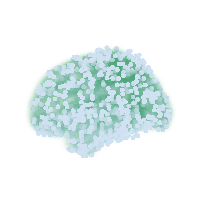

In [76]:
import pyvista as pv

left_src_pvdata = joblib.load(projdir + '/data/icbm09c_left-volume_microarray-pet.pkl')

pl = pv.Plotter(window_size = (200,200))

pl.add_points(pv.PolyData(mni_pet).rotate_z(180), opacity = .05, color = test_colour, point_size = 20, style = "points_gaussian")

pl.add_points(pv.PolyData(left_src_pvdata.points).rotate_z(180), opacity = 1, point_size = 5, color = cv_colour, **point_aes)
pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')


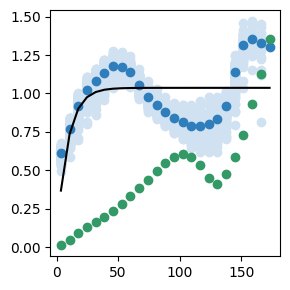

In [77]:
plt.figure( figsize = (3,3) )


for si in range(len(ev_s)):
    plt.scatter(h, joined_vgm[si],color=cv_colour)

plt.scatter(h,joined_vgm[-2,:],color=og_colour)
plt.scatter(z_fulldense_vgm[0], scaled_fulldense_vgm,color=test_colour)
plt.plot(h,joined_vgm[-1,:],color='k')

plt.tight_layout()

* fit exponential model to dense PET map as well & compare parameters

In [78]:
import skgstat as skg
from scipy.optimize import curve_fit

nparams = 3
h,ev,nbins = z_fulldense_vgm

bounds = ([0.00001]*nparams, [np.nanmax(h), np.nanmax(ev), np.nanmax(ev)/nh])

cof, cov = curve_fit(helpers.exponential, h, ev, method = 'trf', \
                     p0=bounds[1], bounds = bounds, maxfev=1000)
v_pred = helpers.exponential(h, *cof)

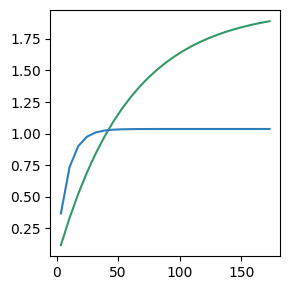

In [79]:
plt.figure(figsize = (3,3))
plt.plot(h,v_pred, color = test_colour)
plt.plot(h,theoretical, color = og_colour)
plt.tight_layout()

In [80]:
r_pet = cof[0]
r_mrna = binned_vario.parameters[0]
print(r_pet); print(r_mrna)

173.09822262551725
26.51671093841796


In [81]:
sill_pet = cof[1] + cof[2]
sill_mrna = binned_vario.parameters[1] + binned_vario.parameters[2]

In [82]:
sill_ratio = sill_pet / sill_mrna
sill_ratio

np.float64(1.9182129806699817)

In [83]:
import numpy as np

ev_test = z_fulldense_vgm[1]
theo_og = theoretical
dense_bins = z_fulldense_vgm[2]

mask = np.isfinite(ev_test) & np.isfinite(theo_og) & (dense_bins > 1000)  # pick threshold
w = dense_bins[mask].astype(float)

diff = ev_test[mask] - theo_og[mask]

wrmse = np.sqrt(np.sum(w * diff**2) / np.sum(w))
wmae  = np.sum(w * np.abs(diff)) / np.sum(w)

print("WRMSE:", wrmse)
print("WMAE :", wmae)

WRMSE: 0.4224312648031982
WMAE : 0.36977878677800136


In [84]:
import pandas as pd
expvgm_df = pd.DataFrame(np.vstack(ev_s))
expvgm_df['parcel'] = expvgm_parcel
expvgm_df['distbin'] = expvgm_distbin
expvgm_df['mae_full'] = mae_cv

In [85]:
df_long = expvgm_df.melt(
    id_vars=["parcel", "distbin", "mae_full"],   # columns to keep
    value_vars=list(range(25)),      # columns 0–24
    var_name="h",                    # new column for former column names
    value_name="ev"                  # new column for values
)

In [86]:
import statsmodels.formula.api as smf

df = df_long
df["parcel"] = df["parcel"].astype("category")
df["distbin"] = df["distbin"].astype("category")

model = smf.ols(
    "mae_full ~ C(distbin) + C(parcel)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               mae_full   R-squared:                       0.509
Model:                            OLS   Adj. R-squared:                  0.505
Method:                 Least Squares   F-statistic:                     192.8
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        12:24:52   Log-Likelihood:                 12495.
No. Observations:                4375   AIC:                        -2.491e+04
Df Residuals:                    4336   BIC:                        -2.466e+04
Df Model:                          38                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.1134      0.001    1

In [87]:
pw = model.t_test_pairwise('C(distbin)')

In [88]:
pw.result_frame

,coef,std err,z,P>|z|,Conf. Int. Low,Conf. Int. Upp.,pvalue-hs,reject-hs
1-0,-0.004551,0.000446,-10.213473,1.725745e-24,-0.005424,-0.003677,3.451490e-24,True
2-0,0.003443,0.000504,6.835542,8.169541e-12,0.002456,0.004430,8.169541e-12,True
3-0,0.012163,0.000580,20.976174,1.082620e-97,0.011027,0.013300,6.495719e-97,True
4-0,0.030175,0.000868,34.774804,5.847641e-265,0.028474,0.031876,5.262877e-264,True
2-1,0.007994,0.000419,19.081316,3.610530e-81,0.007172,0.008815,1.444212e-80,True
3-1,0.016714,0.000508,32.903412,1.964243e-237,0.015718,0.017709,1.571394e-236,True
4-1,0.034726,0.000821,42.274608,0.000000e+00,0.033116,0.036336,0.000000e+00,True
3-2,0.008720,0.000560,15.581379,9.742964e-55,0.007623,0.009817,2.922889e-54,True
4-2,0.026732,0.000854,31.289038,6.578195e-215,0.025058,0.028407,4.604737e-214,True
4-3,0.018012,0.000901,19.982986,7.745005e-89,0.016245,0.019779,3.872503e-88,True


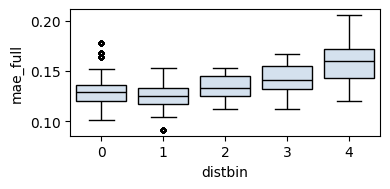

In [89]:
plt.figure(figsize = (4,2))
sns.boxplot(df_long, x='distbin', y='mae_full', fliersize = 3, linecolor = 'k', color = cv_colour)
plt.tight_layout()

### Cross validation ranked performance

In [90]:
import pandas as pd
from interpmodules import metrics
nfolds = 5
gene = 'HTR1A'

dsk33_per_distbin = {}
for lab in np.arange(35):

    cv_parc = joblib.load(projdir + f'/results/distdep_cv/microarray/use_case_microarray_{gene}_dsk-parc{lab}_scores.pkl')

    ranks_by_distbin = pd.DataFrame(columns = np.arange(nfolds), index=approaches)

    for db in range(nfolds):
        
        distbin = pd.DataFrame(columns = approaches, index = metrics_to_consider[:-1])
    
        for approach in approaches:
    
            cv_parc[approach].columns = np.arange(5)
            distbin[approach] = cv_parc[approach][db]
            #print(distbin[approach])
    
        run_rank_scores = metrics.accuracy_rank( distbin )
        #print(distbin)
        run_rank_scores = np.mean(run_rank_scores, axis = 1)
        #print(run_rank_scores)
        ranks_by_distbin[db] = run_rank_scores

    dsk33_per_distbin[lab] = ranks_by_distbin

In [91]:
df_long = pd.DataFrame(columns = ['approach', 'rank', 'parcel', 'distbin'])

for lab in np.arange(35):
    out = (
    dsk33_per_distbin[lab]
    .rename_axis("approach")
    .stack()
    .reset_index(name="rank")
    .rename(columns={"level_1": "distbin"})
    )
    out['parcel'] = lab

    df_long = pd.concat([df_long, out])

In [92]:
results = joblib.load(projdir + f'/results/microarray-pet/all/fsLR-4k_mrna_{gene}_cic-volume_microarray-pet_samp-all_pct-100_0_all_info.pkl')
compare_to_pet = pd.DataFrame(np.vstack([ np.array(results['performance'][1].index), results['performance'][1].to_numpy() ]).T, columns = ['approach', 'rank'])

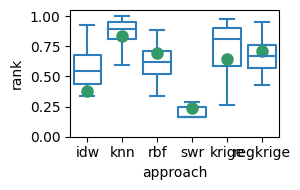

In [97]:
fig, ax = plt.subplots(figsize = (3,2))
sns.boxplot(df_long, x='approach', y='rank',order = aorder, fill=False, fliersize = 0, color=og_colour,legend=False, ax=ax)
sns.pointplot(compare_to_pet, x="approach", y="rank", marker='o', order = aorder, color = test_colour, markersize=7, linestyle='none')
plt.tight_layout()
ax.set_ylim([0,1.05])
plt.yticks([0,0.25,0.5,0.75,1])
plt.show()

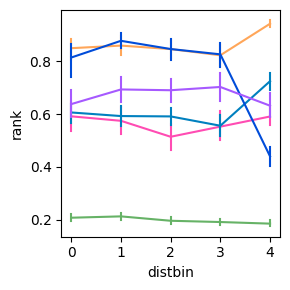

In [98]:
plt.figure(figsize=(3,3))
sns.lineplot(df_long, y='rank', x='distbin', err_style = 'bars', markers = True, hue = 'approach', palette=apal, legend=False)

plt.tight_layout()

In [99]:
import statsmodels.formula.api as smf
df = df_long
df["distbin"] = df["distbin"].astype("category")
df["parcel"] = df["parcel"].astype("category")
df["approach"] = df["approach"].astype("category")

model = smf.ols(
    "rank ~ C(distbin) + C(parcel) + C(approach)",
    data=df
).fit(cov_type="HC3")

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rank   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     200.4
Date:                Tue, 19 May 2026   Prob (F-statistic):               0.00
Time:                        12:26:10   Log-Likelihood:                 580.98
No. Observations:                 922   AIC:                            -1074.
Df Residuals:                     878   BIC:                            -861.6
Df Model:                          43                                         
Covariance Type:                  HC3                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [100]:
df_wide = (
    df_long
    .pivot(index=["parcel", "distbin"], columns="approach", values="rank")
    .reset_index()
)

# optional: remove the column index name ("approach")
df_wide.columns.name = None

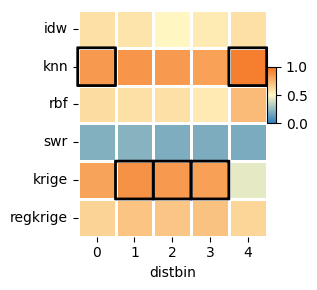

In [101]:
from matplotlib.patches import FancyBboxPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors
from matplotlib import cm

data = df_wide.groupby("distbin").mean(approaches).T
data = data.loc[approaches]
fig, ax = plt.subplots(figsize = (8,3))
sns.heatmap( data, cmap = gnrd, vmin = 0, vmax = 1, linewidth = 2, linecolor = 'w', square = True, cbar = False, ax=ax)

for distbin in data.columns:
    col_label = distbin
    row_label = data[distbin].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))

axins = inset_axes(
    ax,
    width="10%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()

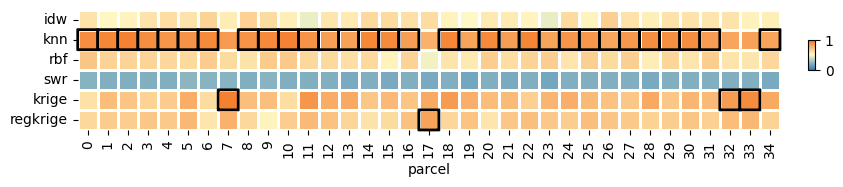

In [102]:
from matplotlib.patches import FancyBboxPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.colors as mcolors
from matplotlib import cm


fig, ax = plt.subplots(figsize = (8,3))

data = df_wide.groupby("parcel").mean(approaches).T
data = data.loc[approaches]

sns.heatmap( data, cmap = gnrd, vmin = 0, vmax = 1, linecolor = 'w', linewidth = 2, square = True, cbar = False, ax=ax)

for parc in data.columns:
    col_label = parc
    row_label = data[parc].sort_values(ascending = False).index[0]

    i = data.index.get_loc(row_label)
    j = data.columns.get_loc(col_label)
    
    #ax.add_patch(
    #    plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="dimgray", linewidth=2)
    #)
    
    ax.add_patch(
        FancyBboxPatch(
            (j, i), 1, 1,
            boxstyle="round,pad=0.0001",
            linewidth=2,
            edgecolor="k",
            facecolor="none", clip_on=False
        ))

axins = inset_axes(
    ax,
    width="2%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower right",
    bbox_to_anchor=(0.55,0.5, 0.5, 0.5),
    bbox_transform=ax.transAxes,
    borderpad=0,
)

norm = mcolors.Normalize(vmin=0, vmax=1)
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=gnrd), cax=axins)

fig.subplots_adjust(right=1.0, bottom = 0.2)

plt.tight_layout()

### Compare with PET with Moran nulls

In [103]:
df, nulldistr = joblib.load(projdir + '/results/use_case_microarray_HTR1A_nulldistr.pkl')

In [104]:
df = df.sort_values(by = 'r', ascending = False)

In [105]:
df

,r,p
knn,0.782508,0.000
krige,0.772502,0.000
rbf,0.770526,0.000
idw,0.748920,0.000
regkrige,0.734977,0.000
swr,-0.017895,0.824


(-0.1, 1.0)

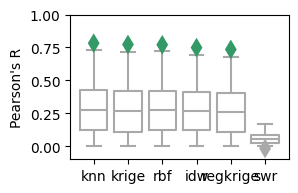

In [107]:
import seaborn as sns
gene = 'HTR1A'
is_significant = df['p'] < .05

fig, ax = plt.subplots(figsize = (3,2))
sns.boxplot(nulldistr, order = df.index, fill=False, fliersize = 0, color = 'darkgray', ax=ax)
ax.scatter(
    df.index[~is_significant],
    df['r'][~is_significant],
    color="darkgray",
    marker = 'd',
    edgecolor = 'none',
    s=100,
    zorder=5,
    label="Not significant"
)
ax.scatter(
    df.index[is_significant],
    df['r'][is_significant],
    color=test_colour,
    marker = 'd',
    edgecolor = 'none',
    s=100,
    zorder=5,
    label="Significant"
)
ax.set_ylabel("Pearson's R")
plt.tight_layout()
ax.set_ylim([-0.1,1])
#plt.show()